# Bilevel LP before solving parametric LP 

__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2023, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Dustin Kenefake", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


## Problem Statement

In the following example a multi-scale energy systems mixed integer linear program (MILP) is reformulated as a mulitparametric linear program (mpLP)

## Nomenclature

*Sets*


$\mathcal{R}$ - set of all resources r

$\mathcal{P}$ - set of all processes p

$\mathcal{T}$ - set of temporal periods t


*Subsets*


$\mathcal{R}^{storage}$ - set of resources that can be stored

$\mathcal{R}^{sell}$ - set of resources that can be discharged

$\mathcal{R}^{demand}$ - set of resources that meet  demand

$\mathcal{R}^{cons}$ - set of resources that can be consumed

$\mathcal{P}^{uncertain-cap}$ - set of processes with uncertain capacity

$\mathcal{P}^{uncertain-capex}$ - set of processes with uncertain capital expenditure

$\mathcal{T}^{net}$ - set of temporal periods t for network level decision making

$\mathcal{T}^{sch}$ - set of temporal periods t for schedule level decision making


*Continuous Variables*


$P_{p,t}$ - production level of p $\in$  $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{sch}$  

$C_{r,t}$ - consumption of r $\in$ in $\mathcal{R}^{cons}$ time period t $\in$ $\mathcal{T}^{sch}$ 

$S_{r,t}$ - discharge of r $\in$ in $\mathcal{R}^{demand}$ time period t $\in$ $\mathcal{T}^{sch}$ 

$Inv_{r,t}$ - inventory level of r $\in$ $\mathcal{R}^{storage}$  in time period t $\in$ $\mathcal{T}^{sch}$

$Cap^S_{r,t}$ - installed inventory capacity for resource r $\in$  $\mathcal{R}^{storage}$ in time period t $\in$ $\mathcal{T}^{net}$

$Cap^P_{p,t}$ - installed production capacity for process p $\in$ $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{net}$




*Binary Variables*


$X^P_{p,t}$ - network binary for production process p $\in$ $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{net}$

$X^S_{r,t}$ - network binary for inventory of resource r  $\mathcal{R}^{storage}$ in time period t $\in$ $\mathcal{T}^{net}$



*Parametric Variables*


$\alpha_{p}$ - uncertainty in production capacity of process p $\in$ $\mathcal{P}^{uncertain-cap}$

$\beta_{r}$ - uncertainty in demand for resource r $\in$ $\mathcal{R}^{demand}$

$\gamma_{r}$ - uncertainty in purchase price for resource r $\in$ $\mathcal{R}^{cons}$

$\delta_{r}$ - uncertainty in consumption availability for resource r $\in$ $\mathcal{R}^{cons}$

$\epsilon_{p}$ - uncertainty in cost of technology for process p $\in$ $\mathcal{P}^{uncertain-capex}$



*Parameters*


$Cap^{P-max}_{p,t}$ - maximum production capacity of process p $\in$ $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{net}$

$Cap^{S-max}_{r,t}$ - maximum inventory capacity for process r $\in$ $\mathcal{R}^{storage}$ in time period t $\in$ $\mathcal{T}^{net}$

$Capex_{p,t}$ - capital expenditure for process p $\in$ $\mathcal{P}$ in time t $\in$ $\mathcal{T}^{net}$

$Vopex_{p,t}$ - variable operational expenditure for process p $\in$ $\mathcal{P}$ in time t $\in$ $\mathcal{T}^{sch}$

$Price_{r,t}$ - purchase price for resource r $\in$ $\mathcal{R}^{cons}$ in time t $\in$ $\mathcal{T}^{sch}$

$C^{max}_{r,t}$ - maximum consumption availability for resource r $\in$ $\mathcal{R}^{cons}$ in time t $\in$ $\mathcal{T}^{sch}$

$D_{r,t}$ - demand for resource r $in$ $\mathcal{R}^{sell}$ in time t $\in$ $\mathcal{T}^{sch}$




# MILP Formulation

Given is a general MILP modeling and optimization framework for simultaneous network design and scheduling.




\begin{equation}
    min \sum_{t \in \mathcal{T}^{net}} \sum_{p \in \mathcal{P}} Capex_{p,t} \times Cap^P_{p,t} + \sum_{t \in \mathcal{T}^{sch}} \sum_{r \in \mathcal{R}^{cons}}  Price_{r,t}  \times C_{r,t} + \sum_{t \in \mathcal{T}^{sch}} \sum_{p \in \mathcal{P}}  Vopex_{r,t} \times P_{r,t} 
\end{equation}


\begin{equation}
    Cap^S_{r,t} \leq Cap^{S-max}_{r,t} \times X^S_{r,t} \hspace{1cm} \forall r \in \mathcal{R}^{storage}, t \in \mathcal{T}^{net}
\end{equation}

\begin{equation}
    Cap^P_{p,t} \leq Cap^{P-max}_{p,t} \times X^P_p  \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{net}
\end{equation} 

\begin{equation}
    P_{p,t} \leq Cap^{P}_{p,t}  \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{sch}
\end{equation} 

\begin{equation}
    Inv_{r,t} \leq Cap^{S}_{r,t}  \hspace{1cm} \forall r \in \mathcal{R}^{storage}, t \in \mathcal{T}^{sch}
\end{equation} 


\begin{equation}
    - S_{r,t} \leq - D_{r,t}  \hspace{1cm} \forall r \in \mathcal{R}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
    C_{r,t} \leq C^{max}_{r,t} \hspace{1cm} \forall r \in \mathcal{R}, t \in \mathcal{T}^{sch}
\end{equation}


\begin{equation}
    - S_{r,t} + \sum_{p \in \mathcal{P}} P_{p,t} \times \eta(p,r) = 0 \hspace{1cm} \forall r \in \mathcal{R}^{sell}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
    -Inv_{r,t} + \sum_{p \in \mathcal{P}} P_{p,t} \times \eta(p,r) = 0 \hspace{1cm} \forall r \in \mathcal{R}^{stored}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
    \sum_{p \in \mathcal{P}} P_{p,t} \times \eta(p,r) + C_{r,t} = 0 \hspace{1cm} \forall r \in \mathcal{R}^{cons}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
    S_{r,t}, C_{r,t}, Inv_{r,t}, P_{p,t}, Cap^P_p, Cap^S_r \in R_{\geq 0}
\end{equation}




## mpLP reformulation

Reformulated as an mpLP


\begin{equation}
    min \hspace{1cm} \sum_{p \in \mathcal{P}} Capex_p \times \epsilon_p \times P_p + \sum_{r \in \mathcal{R}^{cons}} C_r \times \gamma_r 
\end{equation}


\begin{equation}
    Inv_r \leq Cap^{S-max}_r \hspace{1cm} \forall r \in \mathcal{R}^{stored}
\end{equation}

\begin{equation}
    - S_r \leq - D_r \times \beta_r \hspace{1cm} \forall r \in \mathcal{R}^{demand}
\end{equation}

\begin{equation}
    C_r \leq C^{max}_r \times \delta_r \hspace{1cm} \forall r \in \mathcal{R}^{cons} 
\end{equation}

\begin{equation}
    P_p \leq Cap^{P-max}_p \times \alpha_p \hspace{1cm} \forall p \in \mathcal{P}
\end{equation} 

\begin{equation}
    - S_{r} + \sum_{p \in \mathcal{P}} P_{p} \times \eta(p,r) = 0 \hspace{1cm} \forall r \in \mathcal{R}^{sell}
\end{equation}

\begin{equation}
    - Inv_{r} + \sum_{p \in \mathcal{P}} P_{p} \times \eta(p,r) = 0 \hspace{1cm} \forall r \in \mathcal{R}^{stored}
\end{equation}

\begin{equation}
    \sum_{p \in \mathcal{P}} P_{p} \times \eta(p,r) + C_{r} = 0 \hspace{1cm} \forall r \in \mathcal{R}^{cons}
\end{equation}

\begin{equation}
    \alpha_p \in A_p \hspace{1cm} \forall p \in \mathcal{P}
\end{equation}

\begin{equation}
    \beta_r \in B_r \hspace{1cm} \forall r \in \mathcal{R}^{demand}
\end{equation}

\begin{equation}
    \gamma_r \in \Gamma_r \hspace{1cm} \forall r \in \mathcal{R}^{cons}
\end{equation}

\begin{equation}
    \delta_r \in \Delta_r \hspace{1cm} \forall r \in \mathcal{R}^{cons}
\end{equation}

\begin{equation}
    \epsilon_p \in E_p \hspace{1cm} \forall p \in \mathcal{P}
\end{equation}


\begin{equation}
    S_r, C_r, Inv_r, P_p \in R_{\geq 0}
\end{equation}


## Example Problem


\begin{equation}
    p \in \{LI_c, LI_d, WF, PV\} 
\end{equation}


\begin{equation}
    r \in \{charge, power, wind, solar\} 
\end{equation}



\begin{equation}
    min \hspace{1cm} \left[\begin{matrix}1302\\0\\990\\567\end{matrix}\right]^T \left[\begin{matrix}P_{LI_c}\\P_{LI_d}\\P_{WF}\\P_{PV}\end{matrix}\right]
\end{equation}



\begin{equation}
    I_3\left[\begin{matrix}Inv_{charge}\\C_{wind}\\C_{solar}\\P_{LI_c}\\P_{LI_d}\end{matrix}\right] \leq \left[\begin{matrix} 100\\100\\100\\100\\100\end{matrix}\right]
\end{equation}



\begin{equation}
    I_3\left[\begin{matrix}-S_{power}\\P_{WF}\\P_{PV}\end{matrix}\right] \leq \left[\begin{matrix}-300 & 0 & 0\\0 & 100 & 0\\0 & 0 & 100\end{matrix}\right] \left[\begin{matrix}\beta_{power}\\ \alpha_{WF}\\\alpha_{PV}\end{matrix}\right]
\end{equation}



\begin{equation}
    I_4\left[\begin{matrix} - Inv_{charge} \\ -S_{power} \\ C_{wind} \\ C_{solar} \end{matrix}\right] + \left[\begin{matrix}0.89 & -1 & 0 & 0\\-1 & 1 & 0.85 & 0.75\\0 & 0 & -1 & 0\\0 & 0 & 0 & -1\end{matrix}\right] \left[\begin{matrix}P_{LI_c}\\P_{LI_d}\\P_{WF}\\P_{PV}\end{matrix}\right] = 0
\end{equation}



\begin{equation}
    \alpha_p \in \mathcal{A}_p \hspace{1cm} \forall p \in \{WF, PV\} 
\end{equation}

\begin{equation}
    \beta_r \in \mathcal{B}_r \hspace{1cm} \forall r \in \{Power\} 
\end{equation}

$\textbf{Import modules}$

In [1]:
import sys
sys.path.append('../../src')

In [2]:
from energiapy.components.result import Result
# import polytope as pt
from ppopt.plot import parametric_plot
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm
from ppopt.mplp_program import MPLP_Program
from ppopt.mpqp_program import MPQP_Program
import numpy
import pandas
import sympy
from energiapy.model.solve import solve
from energiapy.plot.plot_results import CostY, CostX
from energiapy.plot import plot_results, plot_scenario
from energiapy.model.formulate import formulate, Constraints, Objective, ModelClass
from energiapy.components.scenario import Scenario
from energiapy.components.location import Location
from energiapy.components.process import Process, VaryingProcess
from energiapy.components.resource import Resource, VaryingResource
from energiapy.components.material import Material
from energiapy.components.temporal_scale import TemporalScale
from energiapy.conversion.photovoltaic import solar_power_output
from energiapy.conversion.windmill import wind_power_output
from energiapy.utils.math_utils import min_max, normalize
from itertools import product
from matplotlib import rc
import matplotlib.pyplot as plt 

import pandas
import numpy as np
import matplotlib.pyplot as plt
import keras_tuner
from pandas import read_csv
import math
import h5py
from keras.models import Sequential
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.layers import Dense, Activation, Dropout, LSTM
from scipy.signal import savgol_filter
from keras import backend as K
from keras.optimizers import Adam
import tensorflow as tf
import scipy.stats as stats

In [3]:
coord_houston = (29.56999969482422, -95.05999755859375)
weather_houston = pandas.read_csv('../data/weather_houston.csv', index_col=0)
weather_houston.index = pandas.to_datetime(weather_houston.index, utc = True)

solar = solar_power_output(data= weather_houston, coord=coord_houston, sam = 'cecmod', module_params= 'Canadian_Solar_Inc__CS5P_220M', 
                                   inverter = 'cecinverter', inverter_params= 'ABB__MICRO_0_25_I_OUTD_US_208__208V_', 
                                   temperature_params= 'open_rack_glass_glass', aoi_model= 'no_loss', ac_model= 'sandia', spectral_model= 'no_loss')

wind = wind_power_output(data= weather_houston, roughness_length= 0.1, turbine_type= 'V100/1800', hub_height= 92, 
                                 wind_speed_model= 'logarithmic', density_model = 'ideal_gas', temperature_model = 'linear_gradient', 
                                 power_output_model = 'power_coefficient_curve', density_correction = True, obstacle_height = 0, 
                                 observation_height = 10)

# Get [hourly power demand data](https://www.ercot.com/gridinfo/load/load_hist)  for Houston from ERCOT Coastal region
ercot = pandas.read_csv('../data/ercot.csv', index_col=0)
ercot.index = pandas.to_datetime(ercot.index, utc = True)
ercot.loc['2016-11-06 23:00:00'] = ercot.loc['2016-11-06 22:00:00'] #random missing value
ercot.columns = ['Value']
demand = ercot
index = demand.index


C:\Users\cacodcar\AppData\Local\Temp\ipykernel_23164\1303824365.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_houston.index = pandas.to_datetime(weather_houston.index, utc = True)
C:\Users\cacodcar\AppData\Local\Temp\ipykernel_23164\1303824365.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ercot.index = pandas.to_datetime(ercot.index, utc = True)


In [4]:
solar = normalize(solar)
wind = normalize(wind)
demand = normalize(demand)

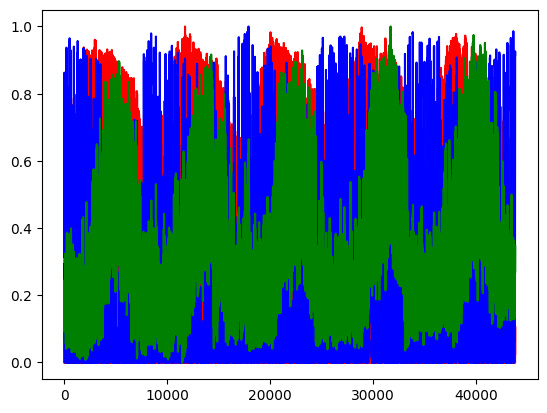

In [5]:
plt.plot(solar, color = 'red')
plt.plot(wind, color = 'blue')
plt.plot(demand, color = 'green')


In [6]:
solar = pandas.DataFrame(data = solar, index= index)
wind = pandas.DataFrame(data = wind, index= index)
demand = pandas.DataFrame(data = demand, index= index)


In [7]:
def runner(filtered_data):
	# convert an array of values into a dataset matrix
	def create_dataset(dataset, look_back=1):
		dataX, dataY = [], []
		for i in range(len(dataset)-look_back-1):
			a = dataset[i:(i+look_back), 0]
			dataX.append(a)
			dataY.append(dataset[i + look_back, 0])
		return np.array(dataX), np.array(dataY)

	all_y = filtered_data.values
	dataset=all_y.reshape(-1, 1)

	# normalize the dataset
	scaler = MinMaxScaler(feature_range=(0, 1))
	dataset = scaler.fit_transform(dataset)

	# split into train and test sets, 30% test data, 70% training data
	train_size = int(len(dataset) * 0.7)
	test_size = len(dataset) - train_size
	train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

	# reshape into X=t and Y=t+1, timestep 240
	look_back = 150
	trainX, trainY = create_dataset(train, look_back)
	testX, testY = create_dataset(test, look_back)

	# reshape input to be [samples, time steps, features]
	trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
	testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

	# model = tf.keras.Sequential([
	#     tf.keras.layers.LSTM(5,return_sequences=True,activation='relu'), 
	#     tf.keras.layers.Dropout(0.10),
	#     tf.keras.layers.LSTM(50,return_sequences=True,activation='relu'),
	#     tf.keras.layers.Dropout(0.10),
	#     tf.keras.layers.LSTM(20),
	# ])

	learning_rate = 0.0005
	model = Sequential()
	model.add(LSTM(64, input_shape=(1, look_back)))
	model.add(Dropout(0.3))
	#model.add(LSTM(50, return_sequences=True, activation='relu'))
	model.add(Dense(1))
	optimizer = Adam(learning_rate=learning_rate)
	model.compile(loss='mse', optimizer=optimizer)

	# Train the model
	history = model.fit(trainX, trainY, epochs=120, batch_size=240, verbose=1, validation_data=(testX, testY))

	# Extract loss values from history
	train_loss = history.history['loss']
	val_loss = history.history['val_loss']

	# Plot training loss and validation loss
	plt.plot(train_loss, label='Train Loss')
	plt.plot(val_loss, label='Validation Loss')
	plt.xlabel('Epochs')
	plt.ylabel('Loss')
	plt.title('Training and Validation Loss')
	plt.legend()
	plt.show()

	def run_monte_carlo_dropout(model, X, n_samples=30):
		"""
		Run Monte Carlo Dropout for making predictions.

		Parameters:
		model (keras.Model): The trained LSTM model.
		X (numpy.array): Input data for predictions.
		n_samples (int): Number of samples to draw.

		Returns:
		numpy.array: Mean predictions.
		numpy.array: Standard deviation of predictions.
		"""
		predictions = np.zeros((n_samples, X.shape[0], X.shape[1]))

		for i in range(n_samples):
			predictions[i] = model.predict(X)

		mean_predictions = np.mean(predictions, axis=0)
		std_predictions = np.std(predictions, axis=0)

		return mean_predictions, std_predictions

	n_samples = 30  # Number of MC Dropout samples
	mean_predictions, std_predictions= run_monte_carlo_dropout(model, testX, n_samples)

	mean_predictions = scaler.inverse_transform(mean_predictions.reshape(-1, 1)).flatten()
	mean_predictions = np.exp(mean_predictions)
	std_predictions = scaler.inverse_transform(std_predictions.reshape(-1, 1)).flatten()
	std_predictions = np.exp(std_predictions) 

	# make predictions
	trainPredict = model.predict(trainX)
	testPredict = model.predict(testX)

	# invert predictions
	trainPredict = scaler.inverse_transform(trainPredict)
	trainPredict = np.exp(trainPredict)
	trainY = scaler.inverse_transform([trainY])
	trainY = np.exp(trainY)
	testPredict = scaler.inverse_transform(testPredict)
	testPredict = np.exp(testPredict)
	testY = scaler.inverse_transform([testY])
	testY = np.exp(testY)

	# calculate root mean squared error
	trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
	print('Train Score: %.2f RMSE' % (trainScore))
	testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
	print('Test Score: %.2f RMSE' % (testScore))
	# Plot original data, mean predictions, and confidence intervals




	plt.plot(testY.flatten(), label='True Values', color= 'blue')
	plt.plot(mean_predictions.flatten(), label='Mean Predictions', color = 'red')
	plt.fill_between(
		range(len(mean_predictions.flatten())),
		mean_predictions.flatten() - 1.44 * std_predictions.flatten(),
		mean_predictions.flatten() + 1.44 * std_predictions.flatten(),
		color='blue', alpha=0.3, label='85% Confidence Intervals'
	)
	plt.fill_between(
		range(len(mean_predictions.flatten())),
		mean_predictions.flatten() - 1.96 * std_predictions.flatten(),
		mean_predictions.flatten() + 1.96 * std_predictions.flatten(),
		color='red', alpha=0.3, label='95% Confidence Intervals'
	)
	plt.legend()
	plt.show()
	last_sequence = dataset[-look_back:]
	num_predictions = 30

	predicted_values = []



	for _ in range(num_predictions):
		last_sequence_reshaped = np.reshape(last_sequence, (1, 1, look_back))
		predicted_value = model.predict(last_sequence_reshaped)
		predicted_values.append(predicted_value[0, 0])
		last_sequence = np.append(last_sequence[1:], predicted_value[0])

	# Invert the predictions back to the original scale
	predicted_values = scaler.inverse_transform([predicted_values])
	predicted_values = np.exp(predicted_values)
	print(predicted_values)
	# Generate a date range for the future predictions
	start_date = pandas.to_datetime(solar.index[-1]) + pandas.DateOffset(days=1)  # Assuming the last date in dt is the latest date
	end_date = start_date + pandas.DateOffset(days=num_predictions-1)
	future_dates = pandas.date_range(start=start_date, end=end_date)
	predicted_values = np.reshape(predicted_values, (num_predictions,))
	predicted_df = pandas.DataFrame(predicted_values, index=future_dates, columns=['Predicted'])


	last_sequence = dataset[-look_back:]
	num_predictions = 24

	predicted_values = []

	for _ in range(num_predictions):
		last_sequence_reshaped = np.reshape(last_sequence, (1, 1, look_back))
		predicted_value = model.predict(last_sequence_reshaped)
		predicted_values.append(predicted_value[0, 0])
		last_sequence = np.append(last_sequence[1:], predicted_value[0])

	# Invert the predictions back to the original scale
	predicted_values = scaler.inverse_transform([predicted_values])
	predicted_values = np.exp(predicted_values)


	future_dates = pandas.date_range(start='2021-01-01 00:00:00+00:00', end='2021-01-01 23:00:00+00:00', freq='H')
	predicted_values = np.reshape(predicted_values, (24,))
	predicted_df = pandas.DataFrame(predicted_values, index=future_dates, columns=['Predicted'])
	predicted_df

	rmse = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
	print('RMSE:', rmse)
	mape = np.mean(np.abs((testY[0] -testPredict[:,0]) / testY[0])) * 100
	print('MAPE:', mape)
	r2 = r2_score(testY[0], testPredict[:,0])
	print('R-squared:', r2)

	def mda(actual, predicted):
		actual_direction = np.sign(np.diff(actual))
		predicted_direction = np.sign(np.diff(predicted))
		correct_directions = np.sum(actual_direction == predicted_direction)
		mda_value = correct_directions / (len(actual_direction) - 1)
		return mda_value

	mda_value = mda(testY[0], testPredict[:,0])
	print('MDA:', mda_value)
	std_p = np.std(predicted_values)
	std_error = std_p/np.sqrt(num_predictions)
	return predicted_df, std_error


	

In [59]:
numpy.std(wind_pred)

Predicted    0.121288
dtype: float64

Epoch 1/120



128/128 [==============================] - 3s 9ms/step - loss: 0.0249 - val_loss: 0.0113
Epoch 2/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0110 - val_loss: 0.0070
Epoch 3/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0080 - val_loss: 0.0053
Epoch 4/120
128/128 [==============================] - 1s 5ms/step - loss: 0.0064 - val_loss: 0.0044
Epoch 5/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0056 - val_loss: 0.0038
Epoch 6/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0050 - val_loss: 0.0033
Epoch 7/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0044 - val_loss: 0.0030
Epoch 8/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 9/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0038 - val_loss: 0.0028
Epoch 10/120
128/128 [==============================] - 1s 4ms/step - loss: 0.0036 - val_loss: 0.0025
E

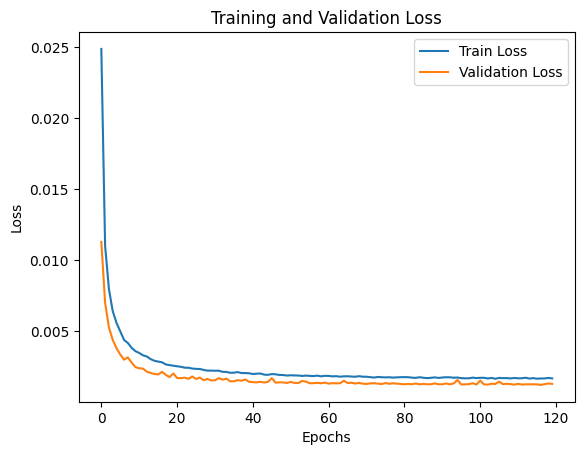

406/406 [==============================] - 1s 1ms/step
Train Score: 0.06 RMSE
Test Score: 0.06 RMSE


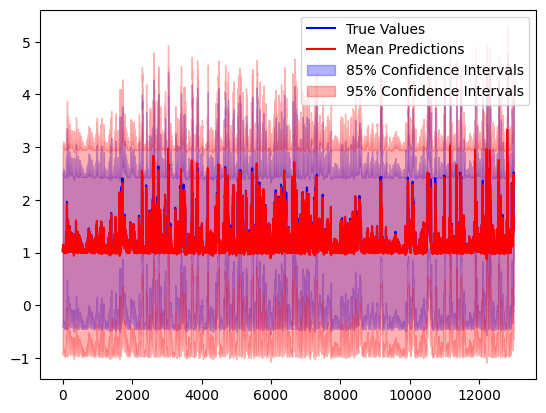

1/1 [==============================] - 0s 23ms/step
[[2.45749462 2.34991953 2.20632924 2.06091466 1.93753358 1.84551329
  1.78584498 1.72918586 1.67607761 1.6107444  1.52349114 1.45033312
  1.42565442 1.44917356 1.49679669 1.5365686  1.56947463 1.56015951
  1.537787   1.4991215  1.44386363 1.36739535 1.2801391  1.22566635
  1.21614952 1.20252883 1.18682575 1.17249954 1.15490221 1.13540158]]
1/1 [==============================] - 0s 24ms/step
RMSE: 0.0580777779980882
MAPE: 2.192730180572828
R-squared: 0.9696764014954362
MDA: 0.6606867878041269


In [8]:
wind_pred, error = runner(wind)

In [9]:
def calculate_confidence_interval(predictions, standard_error, confidence_level=0.95):
    """Calculates the confidence interval for a given set of predictions.

    Args:
        predictions: A list of predictions.
        standard_error: The standard error of the predictions.
        confidence_level: The desired confidence level.

    Returns:
        A list of confidence intervals, where each confidence interval is a tuple of
        (lower bound, upper bound).
    """

    z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    confidence_intervals = []
    for prediction in predictions:
        lower_bound = prediction - z_score * standard_error
        upper_bound = prediction + z_score * standard_error
        confidence_intervals.append((lower_bound, upper_bound))
    confidence_intervals_df = pandas.DataFrame(confidence_intervals, columns=['lower_bound', 'upper_bound'])
    confidence_intervals_df.index = predictions.index
    return confidence_intervals_df



In [57]:
er

0.12128823104806814

In [10]:

ci_99 = calculate_confidence_interval(wind_pred['Predicted'], error, 0.99)
ci_95 = calculate_confidence_interval(wind_pred['Predicted'], error, 0.95)
ci_90 = calculate_confidence_interval(wind_pred['Predicted'], error, 0.90)
ci_85 = calculate_confidence_interval(wind_pred['Predicted'], error, 0.85)

In [11]:
max_ = max(ci_99['upper_bound'])
wind_pred = wind_pred/max_
ci_99 = ci_99/max_
ci_95 = ci_95/max_
ci_90 = ci_90/max_
ci_85 = ci_85/max_

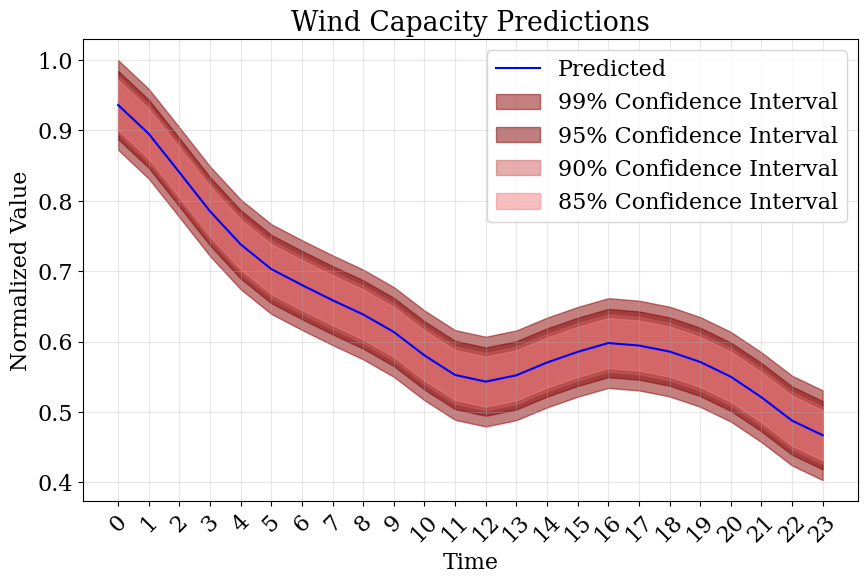

In [12]:
rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize=(10,6))
# ax.scatter(normalize(obj3), normalize(obj4), s=10, color='steelblue')
ax.plot(wind_pred.index, wind_pred['Predicted'], color='blue', label='Predicted')
ax.fill_between(ci_99.index, ci_99['lower_bound'], ci_99['upper_bound'], color='darkred', alpha=0.5, label='99% Confidence Interval')
ax.fill_between(ci_95.index, ci_95['lower_bound'], ci_95['upper_bound'], color='maroon', alpha=0.5, label='95% Confidence Interval')
ax.fill_between(ci_90.index, ci_90['lower_bound'], ci_90['upper_bound'], color='indianred', alpha=0.5, label='90% Confidence Interval')
ax.fill_between(ci_85.index, ci_85['lower_bound'], ci_85['upper_bound'], color='lightcoral', alpha=0.5, label='85% Confidence Interval')


# ax = axis_formatter(axes=ax, xcord=x_, axis_labels='M')
# ax.set_xticklabels(list(range(24)))

xtick_positions = np.linspace(0, 24, 24)

plt.xticks(wind_pred.index, list(range(24)), rotation = 45)
plt.legend()
plt.title(f'Wind Capacity Predictions')
plt.xlabel("Time")
plt.ylabel("Normalized Value")
plt.grid(alpha=0.3)
plt.rcdefaults()

In [32]:

scales = TemporalScale(discretization_list=[1])

Solar = Resource(name='Solar', cons_max=100, basis='MW', label='Solar Power')

Wind = Resource(name='Wind', cons_max=100, basis='MW', label='Wind Power')

Power = Resource(name='Power', basis='MW', label='Power generated', demand = True)#, varying = [VaryingResource.UNCERTAIN_DEMAND], 
                #  varying_bounds  = (demand_ci['lower_bound'][index_],demand_ci['upper_bound'][index_]))#(min(demand['COAST']), 1))
H2O = Resource(name='H2O', cons_max=500, basis='tons', label='Water')

O2 = Resource(name='O2', sell=True, basis='tons', label='Oxygen')

H2 = Resource(name='H2', basis='tons', label='Hydrogen', demand= True) #, varying = [VaryingResource.UNCERTAIN_DEMAND], varying_bounds  = (0.6, 0.8))

Uranium = Resource(name='Uranium', cons_max=1000,
                price=42.70/(250/2), basis='kg', label='Uranium')

LiI = Process(name='LiI', storage=Power, vopex=1302, capex=0, fopex=0,  prod_max=200,
            storage_loss=0.11,  label='Lithium-ion battery', basis='MW', store_max=200)

WF = Process(name='WF', conversion={Wind: -1, Power: 0.85}, vopex=990, capex=0, fopex=0,
            prod_max=100, label='Wind mill array', basis='MW', varying = [VaryingProcess.UNCERTAIN_CAPACITY], 
            varying_bounds = (0,1))

PV = Process(name='PV', conversion={Solar: -1, Power: 0.75}, vopex=567, capex=0, fopex=0,
            prod_max=100, label='Solar PV', basis='MW')#, varying = [VaryingProcess.UNCERTAIN_CAPACITY], 
            # varying_bounds = (solar_ci['lower_bound'][index_],solar_ci['upper_bound'][index_]))

PEM = Process(name='PEM', conversion={Power: -1, H2: 0.3537, H2O: -3.1839}, capex=0, fopex=0,
            vopex=1.55*10**3, prod_max=100, prod_min = 0, basis = 'tons', label = 'PEM' )

ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3.364, Power: 1},
            capex=7988951, fopex=0.04*0.730, vopex=7988, prod_max=100, label='Small modular reactors (SMRs)', block='power_gen')

region = Location(name='region', processes={
                LiI, WF, ASMR}, scales=scales, label='some region wo dispatchable')
scenario = Scenario(name='example', demand={region: {Power:60}}, network=region, scales=scales, label='example scenario')
matrix = formulate(scenario=scenario, model_class=ModelClass.MPLP)
# print(matrix)
# return matrix
# print(scenario.b_df)



The problem has the following variables:
Resource inventory level (Inv) x 1
Exact resource discharge (Sf) x 1
Uncertain resource discharge (S) x 0
Exact resource availability (Af) x 3
Uncertain resource availability (A) x 0
Exact resource price (Cf) x 3
Uncertain resource price (C) x 0
Exact process production (Pf) x 3
Uncertain process production (P) x 1
 For a total of 9 (8 fixed, and 1 uncertain)


In [33]:
prog = MPLP_Program(matrix['A'], matrix['b'], matrix['c'], matrix['H'],
                    matrix['CRa'], matrix['CRb'], matrix['F'], equality_indices=list(range(matrix['no_eq_cons'])))

In [34]:
matrix['A'][0][6] = -1 
matrix['A'][0][7] = 1 

In [35]:
scenario.c_df

,0
Inv_LiI_Power_stored,0.0000
Sf_Power,0.0000
Af_H2O,0.0000
Af_Uranium,0.3416
Af_Wind,0.0000
Pf_ASMR,7988.0000
Pf_LiI,1302.0000
Pf_LiI_discharge,0.0000
P_WF,990.0000


In [36]:
scenario.make_conversion_df()

,H2O,Power,Wind,LiI_Power_stored,Uranium
LiI,0.000,-1.00,0.0,1.0,0.000000
WF,0.000,0.85,-1.0,0.0,0.000000
ASMR,-3.364,1.00,0.0,0.0,-0.000042
LiI_discharge,0.000,0.89,0.0,-1.0,0.000000


In [37]:
scenario.A_df

,Inv_LiI_Power_stored,Sf_Power,Af_H2O,Af_Uranium,Af_Wind,Pf_ASMR,Pf_LiI,Pf_LiI_discharge,P_WF
MB_H2O(=),1.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.00,0.00
MB_LiI_Power_stored(=),0.0,-1.0,0.0,0.0,0.0,1.000000,-1.0,0.89,0.85
MB_Power(=),0.0,0.0,1.0,0.0,0.0,-3.364000,0.0,0.00,0.00
MB_Uranium(=),0.0,0.0,0.0,1.0,0.0,-0.000042,0.0,0.00,0.00
MB_Wind(=),0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.00,-1.00
Inv_LiI_Power_stored(<),1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.00
Sf_Power(>),0.0,-1.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.00
Af_H2O(<),0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.00,0.00
Af_Uranium(<),0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.00,0.00
Af_Wind(<),0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.00,0.00


In [38]:
prog.display_latex()

$$\min_{x}\left[\begin{matrix}0\\0\\0\\0.3416\\0\\7.988e+03\\1.302e+03\\0\\990.0\end{matrix}\right]^T\left[\begin{matrix}x_{0}\\x_{1}\\x_{2}\\x_{3}\\x_{4}\\x_{5}\\x_{6}\\x_{7}\\x_{8}\end{matrix}\right]$$
$$\left[\begin{matrix}1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 1.0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1.0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 1.0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 1.0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 1.0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1.0\\-1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & -1.0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & -1.0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & -1.0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & -1.0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & -1.0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1.0\end{matrix}\right]\left[\begin{matrix}x_{0}\\x_{1}\\x_{2}\\x_{3}\\x_{4}\\x_{5}\\x_{6}\\x_{7}\\x_{8}

$$\min_{x}\left[\begin{matrix}0\\0\\0\\0.3416\\0\\7.988e+03\\1.302e+03\\0\\990.0\end{matrix}\right]^T\left[\begin{matrix}x_{0}\\x_{1}\\x_{2}\\x_{3}\\x_{4}\\x_{5}\\x_{6}\\x_{7}\\x_{8}\end{matrix}\right]$$
$$\left[\begin{matrix}1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 1.0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1.0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 1.0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 1.0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 1.0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1.0\\-1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & -1.0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & -1.0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & -1.0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & -1.0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & -1.0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & -1.0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1.0\end{matrix}\right]\left[\begin{matrix}x_{0}\\x_{1}\\x_{2}\\x_{3}\\x_{4}\\x_{5}\\x_{6}\\x_{7}\\x_{8}\end{matrix}\right]\leq\left[\begin{matrix}30.0\\-100.0\\500.0\\1e+03\\100.0\\100.0\\100.0\\100.0\\100.0\\0\\0\\0\\0\\0\\0\\0\\0\\0\end{matrix}\right]+\left[\begin{matrix}0\\0\\0\\0\\0\\0\\0\\0\\-1.0\\0\\0\\0\\0\\0\\0\\0\\0\\0\end{matrix}\right]\left[\begin{matrix}\theta_{0}\end{matrix}\right]$$
$$\left[\begin{matrix}1.0 & 0 & 0 & 0 & 0 & 0 & 1.0 & -1.0 & 0\\0 & -1.0 & 0 & 0 & 0 & 1.0 & -1.0 & 0.89 & 0.85\\0 & 0 & 1.0 & 0 & 0 & -3.364 & 0 & 0 & 0\\0 & 0 & 0 & 1.0 & 0 & -1.0 10^{4.1700000000000004e-05} & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1.0 & 0 & 0 & 0 & -1.0\end{matrix}\right]\left[\begin{matrix}x_{0}\\x_{1}\\x_{2}\\x_{3}\\x_{4}\\x_{5}\\x_{6}\\x_{7}\\x_{8}\end{matrix}\right]=\left[\begin{matrix}0\\0\\0\\0\\0\end{matrix}\right]+\left[\begin{matrix}0\\0\\0\\0\\0\end{matrix}\right]\left[\begin{matrix}\theta_{0}\end{matrix}\right]$$
$$\left[\begin{matrix}1.0\\-1.0\end{matrix}\right]\left[\begin{matrix}\theta_{0}\end{matrix}\right]\leq\left[\begin{matrix}1.0\\0\end{matrix}\right]$$

In [39]:
time_periods = 24

In [40]:
from scipy.linalg import block_diag
A = block_diag(*[matrix['A'] for x in range(time_periods)])

In [41]:
for i in range(time_periods -1):
    x_cord = i*9
    y_cord = (i+1)*(23)
    A[y_cord, x_cord] = -1

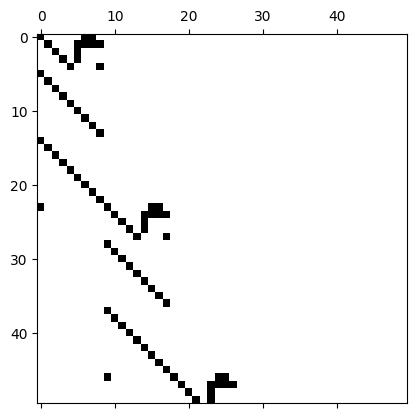

In [42]:
plt.spy(A[:50,:50])

In [43]:
c = numpy.vstack([matrix['c'] for _ in range(time_periods)])

In [44]:
F = numpy.vstack([matrix['F'] for _ in range(time_periods)])

In [45]:
b = numpy.vstack([matrix['b'] for _ in range(time_periods)])

In [46]:
for i in range(time_periods):
    b[23*i+13] = wind_pred.to_numpy()[i]*100

In [47]:
A_t = numpy.array([[1],[-1]])
b_t = numpy.array([[6],[0]])


# make the quality indices

eqs = [[0+i*23,1+i*23,2+i*23,3+i*23,4+i*23] for i in range(time_periods)]
eqs = sum(eqs, [])
# eqs

In [48]:
from ppopt.mplp_program import MPLP_Program
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm

prog = MPLP_Program(A, b, c, numpy.zeros((1,time_periods*9)).T,
                    A_t, b_t, F, equality_indices=eqs)

In [49]:
from pickle import dump

dump(prog, open('mama_mia10.dummpy', 'wb'))

In [31]:
prog.solver.solvers['lp'] = 'gurobi'
# prog.warnings()
prog.display_warnings()
prog.process_constraints()
results = solve_mpqp(prog, mpqp_algorithm.graph)


Set parameter Username
Academic license - for non-commercial use only - expires 2024-02-14
[]
First region (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 125, 127, 128, 130, 132, 135, 139, 141, 142, 144, 146, 149, 153, 155, 156, 158, 159, 163, 167, 173, 174, 177, 181, 187, 188, 191, 195, 201, 202, 205, 209, 210, 215, 219, 223, 224, 229, 230, 233, 237, 238, 243, 244, 247, 251, 252, 257, 258, 261, 265, 266, 271, 272, 275, 279, 280, 285, 286, 289, 293, 294, 299, 300, 303, 307, 308, 313, 314, 317, 321, 322, 327, 328, 331, 335, 336, 341, 342, 345, 34

KeyboardInterrupt: 

In [ ]:
len(results.critical_regions)

2

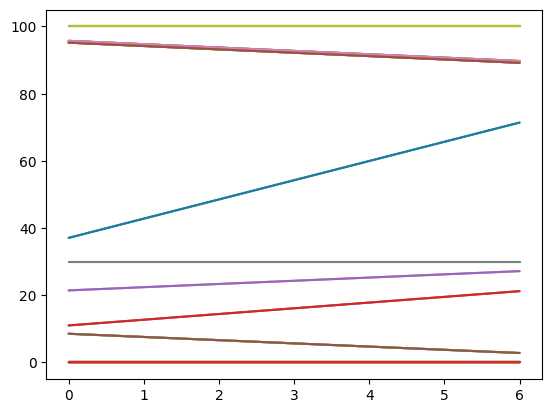

In [ ]:
from ppopt.plot import parametric_plot_1D

parametric_plot_1D(results)

In [ ]:
results.critical_regions

[Critical region with active set [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 15, 21, 24, 25, 29, 34, 35]
 The Omega Constraint indices are [0, 1]
 The Lagrange multipliers Constraint indices are []
 The Regular Constraint indices are [[], []]
   x(θ) = Aθ + b 
  λ(θ) = Cθ + d 
   Eθ <= f
  A = [[-9.55056180e-01]
  [ 3.55667545e-16]
  [ 5.71880000e+00]
  [ 7.08900000e-05]
  [-1.00000000e+00]
  [ 1.70000000e+00]
  [-2.36648108e-15]
  [-9.55056180e-01]
  [-1.00000000e+00]
  [ 2.84744344e-16]
  [-9.88106033e-16]
  [-2.00763379e-15]
  [ 3.61359152e-16]
  [-1.00000000e+00]
  [-3.39223740e-16]
  [-1.15243347e-15]
  [ 9.55056180e-01]
  [-1.00000000e+00]] 
  b = [[ 8.54771333e+00]
  [ 1.00000000e+02]
  [ 3.70881871e+01]
  [ 4.59743579e-04]
  [ 9.57264815e+01]
  [ 1.10250259e+01]
  [ 1.63566334e-14]
  [ 8.54771333e+00]
  [ 9.57264815e+01]
  [ 3.00000000e+01]
  [ 1.00000000e+02]
  [ 1.78367665e-13]
  [ 1.59284622e-14]
  [ 9.51852528e+01]
  [ 6.89195348e-14]
  [-2.50610928e-14]
  [ 2.14522867e+01]
  [ 9.51